# **Combined model** — Allen-Cahn $\oplus$ Model B $\oplus$ KPZ (d = 1)

One SPDE that stitches together the *unique* nonlinearity of each class:

$$\partial_t\phi = -\mu\phi + D\,\partial_x^2\phi
  \;\underbrace{-\,\lambda\phi^3}_{\text{Allen-Cahn (}\phi^4\text{ potential)}}
  \;\underbrace{+\,g\,\partial_x^2(\phi^2)}_{\text{Model B (conserved }\nabla^2\text{)}}
  \;\underbrace{+\,\tfrac{\kappa}{2}(\partial_x\phi)^2}_{\text{KPZ (per-leg gradient)}}
  \;+\;\eta,\qquad \langle\eta\eta\rangle = 2T\,\delta\,\delta.$$

- **Allen-Cahn** — the relaxational $-\lambda\phi^3$ (a plain polynomial vertex).
- **Model B** — the *conserving* $g\,\partial_x^2(\phi^2)$ (a **composite**-$\nabla$ derivative vertex).
- **KPZ** — the *roughening* $\tfrac{\kappa}{2}(\partial_x\phi)^2$ (a **per-leg**-$\partial_x$ derivative vertex).

**The diagrammatic theory now computes** — the per-vertex form-factor table
(`ns._operator_ir_vertex_terms`) lets each interaction vertex carry its own
factor, so a φ̃φ² node sums the Model B ($\nabla^2$) and KPZ ($\partial_x$)
contributions coupling-weighted ($\Sigma_t\,w_t\,\mathfrak f_t$) and a mixed
diagram reconstructs every cross term — no single-mode gate.

**Caveat for THIS combination:** the Model B $\times$ KPZ *cross* bubble has a
degree-4 loop form factor ($\mathfrak f_{\rm MB}\!\sim\!\ell^2$ times
$\mathfrak f_{\rm KPZ}\!\sim\!\ell^2$), so its momentum loop is **UV-divergent**
in $d=1$ — mixing a *conserved* $\nabla^2(\phi^2)$ with a *non-conserved*
$(\partial\phi)^2$ generates a UV-relevant cross operator.  The bare equal-time
variance is therefore **UV-dominated** (it can go negative) and needs
renormalisation; the single-vertex limits ($g$ only, $\kappa$ only, $\lambda$
only) are each finite and physical.  **The simulation runs the full SPDE
regardless** — that is the clean object to look at.

In [1]:
import os, sys, time
# --- depth-robust repo root ---
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'pipeline')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
os.chdir(os.path.join(_root, 'notebooks'))
sys.path.insert(0, os.path.join(_root, 'notebooks'))   # daedalus on the path
import numpy as np
import matplotlib.pyplot as plt
import daedalus as dd
from models.spatial_field_1d_sim import simulate, equal_time_correlator

def order_label(ell):
    return ('tree' if ell == 0 else
            'tree + ' + ' + '.join('%d-loop' % j for j in range(1, ell + 1)))

# physics: mass, diffusion, φ³ (Allen-Cahn), ∇²(φ²) (Model B), (∂ₓφ)² (KPZ), noise temp
mu, D, lam, g, kpz, T = 1.0, 1.0, 0.1, 0.15, 0.3, 1.0

# The combined Allen-Cahn ⊕ Model B ⊕ KPZ (d=1) theory now lives in a shared
# theory file, loaded through the daedalus engine (build() reproduces the
# former inline TheoryBuilder verbatim; field name is the d-prefixed 'dphi').
model, mod = dd.load_theory('combined_allencahn_modelb_kpz_1d')

## 0. Choose the order + parameters

In [2]:
# ============================  CHOOSE THE ORDER  ============================
MAX_ELL    = 1      # loop order ℓ:  0 = tree,  1 = +1-loop
K_EXTERNAL = 2      # correlator order k:  2 = two-point ⟨φφ⟩
VERBOSE    = False  # staged [1/7]…[7/7] trace per order
# ===========================================================================

xs = np.linspace(0.0, 6.0, 25)                       # output separations χ ≥ 0
fund = {'mu': mu, 'D': D, 'lam': lam, 'g': g, 'kpz': kpz, 'T': T}
orders = list(range(0, MAX_ELL + 1))

# analytic FREE tree reference (λ=g=κ=0):  C₀(x) = T/(2√(μD)) · e^{−√(μ/D)|χ|}
C0_amp = T / (2.0 * np.sqrt(mu * D))
C0_x = C0_amp * np.exp(-np.sqrt(mu / D) * np.abs(xs))
print('free tree C₀(0,0) = %.4f  (reference baseline)' % C0_amp)

free tree C₀(0,0) = 0.5000  (reference baseline)


## 1. Theory — multi-derivative-vertex (now computes; cross is UV-sensitive)

In [3]:
# The per-vertex form-factor table lets this multi-derivative-vertex theory
# compute (no gate).  NOTE: the Model B × KPZ cross bubble is UV-divergent
# (degree-4 loop form factor), so the bare combined variance is UV-DOMINATED and
# can be negative — a real feature of mixing conserved ∇²(φ²) + non-conserved
# (∂φ)², not a bug (each single-vertex limit is finite).  Try the isolated
# couplings (set g, kpz, lam individually in the theory file) to see the clean
# physical pieces.
#
# Engine: the theory is loaded from theories/combined_allencahn_modelb_kpz_1d
# via dd.load_theory (cell above).  The loop here calls compute_cumulants on
# that loaded model with the SAME validated kwargs as the original notebook —
# in particular use_cache=False, which is load-bearing: the on-disk expand
# cache for this theory can hold a stale (pre-form-factor) entry that silently
# drops the composite+perleg vertex mode and corrupts the 1-loop value, so the
# combined derivative-vertex physics MUST be run uncached.  The external field
# is the d-prefixed fluctuation 'dphi'.
from pipeline.compute import compute_cumulants

kw = dict(k=K_EXTERNAL, external_fields=[('dphi', 1), ('dphi', 1)],
          chi_grid=xs, tau_max=0.0, tau_step=1.0, verbose=VERBOSE,
          use_cache=False, mf_dae_n_starts=4)
curves, theory_ok, results = {}, True, {}
try:
    for ell in orders:
        t0 = time.time()
        out = compute_cumulants(model, max_ell=ell, fundamental=fund, **kw)
        results[ell] = out
        mid = out['C_tau_x'].shape[0] // 2
        curves[ell] = np.real(out['C_tau_x'])[mid]
        si = out.get('spatial_info', {}) or {}
        print('%-26s C(0,0) = %.4f   mode = %s   (%.0fs)'
              % (order_label(ell), curves[ell][0], si.get('vertex_mode', '—'),
                 time.time() - t0))
    if curves.get(MAX_ELL, [1])[0] < 0:
        print('\n[note] C(0,0) < 0 — the UV-divergent Model B × KPZ cross term '
              'dominates the bare variance (needs renormalisation).')
except Exception as e:
    theory_ok = False
    print('THEORY raised: %s' % e)

tree                       C(0,0) = 0.5000   mode = —   (2s)


tree + 1-loop              C(0,0) = -0.8875   mode = composite+perleg   (2s)

[note] C(0,0) < 0 — the UV-divergent Model B × KPZ cross term dominates the bare variance (needs renormalisation).


## 2. Simulation — the FULL combined SPDE

In [4]:
# Full combined SPDE: −λφ³ (lam) + g∇²(φ²) (g_lap) + (κ/2)(∂ₓφ)² (lam_kpz).
snaps, x_grid, meta = simulate(L=20.0, N=128, mu=mu, D=D, T=T,
                               lam=lam, g_lap=g, lam_kpz=kpz, dt=0.02,
                               n_steps=120000, burn_in=20000, record_every=20, seed=1)
if not np.all(np.isfinite(snaps)) or np.max(np.abs(snaps)) > 30:
    print('WARNING: the simulation blew up — reduce a coupling (g is the stiff one), '
          'raise N, or shrink dt.')
mean = float(np.mean(snaps))                         # ⟨φ⟩: the KPZ excess velocity ≠ 0
Cx_full = equal_time_correlator(snaps) - mean**2     # CONNECTED correlator (subtract ⟨φ⟩²)
half = len(x_grid) // 2 + 1
xc, Cx = x_grid[:half], Cx_full[:half]
print('combined-SPDE simulation ran:')
print('   ⟨φ⟩ (KPZ excess velocity)   = %.4f' % mean)
print('   connected C(0,0) = ⟨φ²⟩−⟨φ⟩² = %.4f   (free-tree reference %.4f)' % (Cx[0], C0_amp))
print('   max|φ| = %.3f' % float(np.max(np.abs(snaps))))

combined-SPDE simulation ran:
   ⟨φ⟩ (KPZ excess velocity)   = 0.3509
   connected C(0,0) = ⟨φ²⟩−⟨φ⟩² = 0.4405   (free-tree reference 0.5000)
   max|φ| = 3.783


## 3. Result — simulation vs the free-tree reference

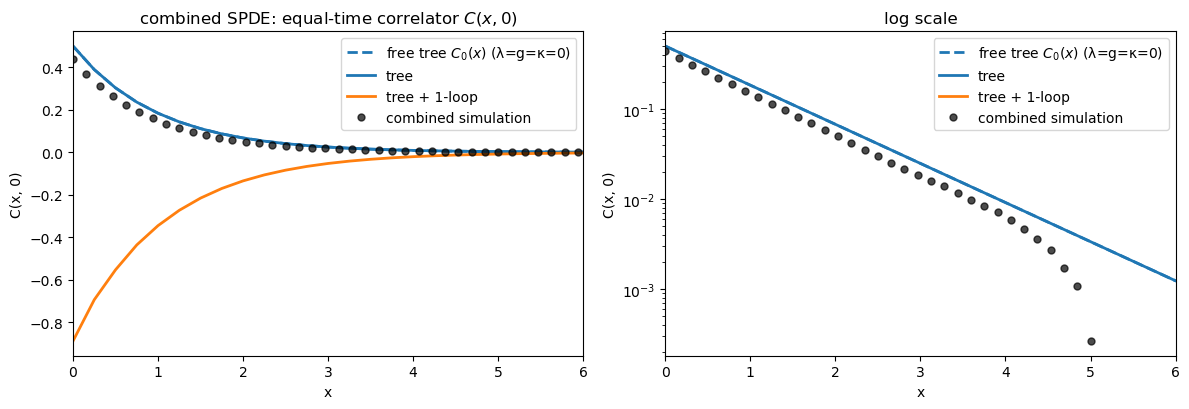

combined-model simulation: ⟨φ²⟩_connected = 0.4405, excess velocity ⟨φ⟩ = 0.3509


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for a in ax:
    a.plot(xs, C0_x, '--', lw=2, color='C0', label=r'free tree $C_0(x)$ (λ=g=κ=0)')
    if theory_ok:
        for ell in orders:
            a.plot(xs, curves[ell], '-', lw=2, label=order_label(ell))
    a.plot(xc, Cx, 'o', ms=5, color='k', alpha=0.7, label='combined simulation')
    a.set_xlabel(r'$\chi$'); a.set_ylabel('C(χ, 0)'); a.set_xlim(0, xs.max())
ax[0].set_title('combined SPDE: equal-time correlator $C(χ,0)$'); ax[0].legend()
ax[1].set_yscale('log'); ax[1].set_title('log scale'); ax[1].legend()
plt.tight_layout(); plt.show()

print('combined-model simulation: ⟨φ²⟩_connected = %.4f, excess velocity ⟨φ⟩ = %.4f'
      % (Cx[0], mean))
if not theory_ok:
    print('(diagrammatic theory: multi-derivative-vertex — frontier/gated; sim is the live result)')

## Summary

This **combined model** stresses three nonlinearities at once: Allen-Cahn
$-\lambda\phi^3$, Model B $g\,\partial_x^2(\phi^2)$, and KPZ
$\tfrac{\kappa}{2}(\partial_x\phi)^2$.

- **Diagrammatic theory** — now computes via the per-vertex form-factor table
  (each φ̃φ² node sums the composite Model B and per-leg KPZ contributions,
  coupling-weighted; mixed diagrams get every cross term).  Each *single-vertex*
  limit is finite and physical (Model B, KPZ, Allen-Cahn).  The **Model B × KPZ
  cross** bubble is UV-divergent in $d=1$ (degree-4 loop form factor), so the
  bare combined variance is UV-dominated — a real feature of mixing a conserved
  and a non-conserved gradient vertex (it needs a counterterm).
- **Simulation** — runs the full SPDE (all three forcings: `lam`, `g_lap`,
  `lam_kpz`); the KPZ term gives the excess velocity $\langle\phi\rangle\neq0$,
  subtracted in the connected correlator.

**Knobs:** `lam` (φ³), `g` (conserved ∇² — the stiff one; reduce if the sim
blows up), `kpz` (gradient), `mu`, `D`, `T`.  Set couplings individually to see
the clean single-vertex pieces.